In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time

In [2]:
model = YOLO("yolov8n.pt")
import os
model_path = "yolov8n.pt"
size_mb = os.path.getsize(model_path) / (1024*1024)
print(f"Model size: {size_mb:.1f} MB")
print(f"Well within the 300MB limit ✓")

⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.1.0/yolov8n.pt...


##################################################################        92.7%

Model size: 6.2 MB
Well within the 300MB limit ✓


######################################################################## 100.0%



image 1/1 /Users/abhayyadav/aerial-guardian/notebooks/../data/VisDrone2019-MOT-val/sequences/uav0000086_00000_v/0000001.jpg: 384x640 20 persons, 260.1ms
Speed: 11.4ms preprocess, 260.1ms inference, 24.3ms postprocess per image at shape (1, 3, 384, 640)


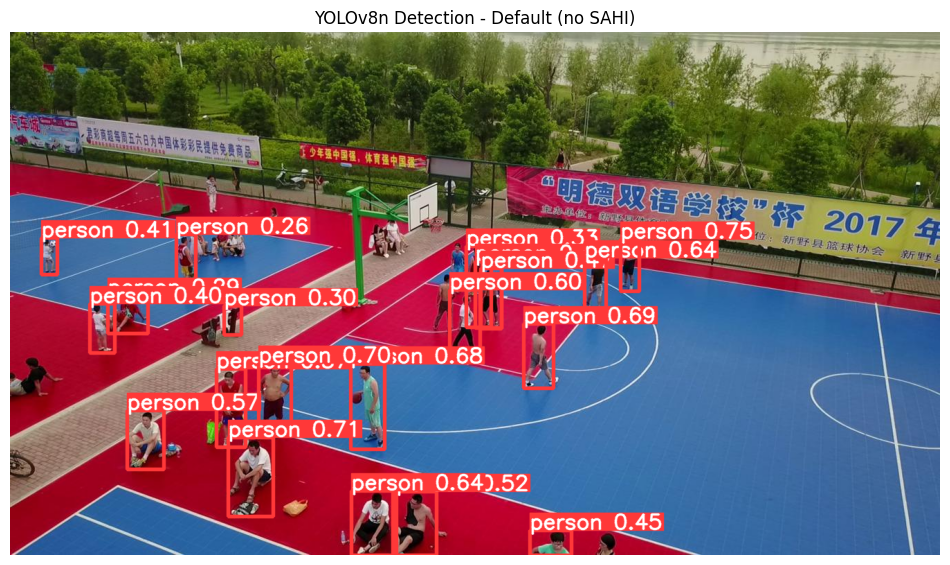

Persons detected: 20


In [3]:
frame_path = "../data/VisDrone2019-MOT-val/sequences/uav0000086_00000_v/0000001.jpg"

results = model(frame_path, 
                classes=[0],
                conf=0.25,
                imgsz=640)

img = results[0].plot()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,8))
plt.imshow(img_rgb)
plt.title("YOLOv8n Detection - Default (no SAHI)")
plt.axis('off')
plt.savefig("../results/detection_v1_sample.png")
plt.show()

print(f"Persons detected: {len(results[0].boxes)}")